# Image Captioning (CNN Encoder + RNN/Transformer Decoder)

1. EDA dataset: Understand caption length distribution, vocabulary size, image diversity,...

2. Train CNN encoder + decoder

3. Evaluation: BLEU/ROUGE,...

4. Deploy: Upload image → generated caption

In [1]:
!pip install nltk rouge-score gradio -q

  Preparing metadata (setup.py) ... done


In [2]:
# Tải Flickr8k dataset
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip

# Giải nén
!unzip -q Flickr8k_Dataset.zip
!unzip -q Flickr8k_text.zip

# Xóa file zip cho gọn
!rm Flickr8k_Dataset.zip Flickr8k_text.zip

print("✅ Dataset ready!")


✅ Dataset ready!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


📊 Số ảnh: 8092
📊 Mỗi ảnh có: 5 captions
📊 Độ dài caption trung bình: 11.8 từ
📊 Max length: 38, Min length: 1


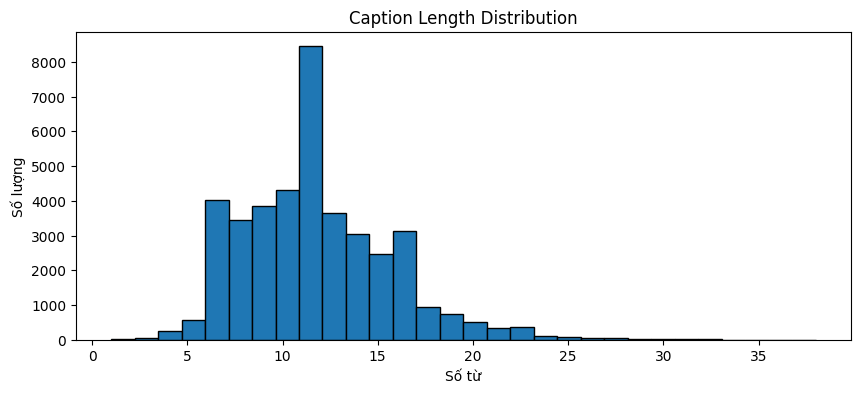

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import nltk
from tqdm.auto import tqdm
nltk.download('punkt')
nltk.download('punkt_tab')

# EDA nhanh
captions_file = 'Flickr8k.token.txt'

def load_captions(file_path):
    captions_dict = {}
    with open(file_path, 'r') as f:
        for line in f:
            img_name, caption = line.strip().split('\t')
            img_name = img_name.split('#')[0]
            if img_name not in captions_dict:
                captions_dict[img_name] = []
            captions_dict[img_name].append(caption)
    return captions_dict

captions_dict = load_captions(captions_file)
print(f"📊 Số ảnh: {len(captions_dict)}")
print(f"📊 Mỗi ảnh có: {len(list(captions_dict.values())[0])} captions")

# Thống kê nhanh
all_lengths = []
for caps in captions_dict.values():
    for cap in caps:
        all_lengths.append(len(nltk.word_tokenize(cap.lower())))

print(f"📊 Độ dài caption trung bình: {np.mean(all_lengths):.1f} từ")
print(f"📊 Max length: {max(all_lengths)}, Min length: {min(all_lengths)}")

# Vẽ histogram
plt.figure(figsize=(10,4))
plt.hist(all_lengths, bins=30, edgecolor='black')
plt.title('Caption Length Distribution')
plt.xlabel('Số từ')
plt.ylabel('Số lượng')
plt.show()

In [4]:
class Vocabulary:
    def __init__(self, freq_threshold=5):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {v: k for k, v in self.itos.items()}
        self.freq_threshold = freq_threshold

    def build_vocabulary(self, captions_list):
        word_counts = Counter()
        for caption in captions_list:
            tokens = nltk.word_tokenize(caption.lower())
            word_counts.update(tokens)

        for word, count in word_counts.items():
            if count >= self.freq_threshold:
                idx = len(self.itos)
                self.itos[idx] = word
                self.stoi[word] = idx

        print(f"📚 Vocabulary size: {len(self.itos)}")

    def numericalize(self, text):
        tokens = nltk.word_tokenize(text.lower())
        return [self.stoi["<SOS>"]] + \
               [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokens] + \
               [self.stoi["<EOS>"]]

# Tạo vocab
all_captions = []
for caps in captions_dict.values():
    all_captions.extend(caps)

vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(all_captions)

print(f"📚 Test: 'a dog runs' -> {vocab.numericalize('a dog runs')}")

📚 Vocabulary size: 3005
📚 Test: 'a dog runs' -> [1, 4, 29, 123, 2]


In [5]:
class FlickrDataset(Dataset):
    def __init__(self, img_dir, captions_dict, vocab, transform=None):
        self.img_dir = img_dir
        self.captions_dict = captions_dict
        self.vocab = vocab
        self.transform = transform

        # Filter image names to ensure they exist on disk
        all_img_names = list(captions_dict.keys())
        self.imgs = []
        for img_name in all_img_names:
            img_path = os.path.join(self.img_dir, img_name)
            if os.path.exists(img_path):
                self.imgs.append(img_name)
            else:
                print(f"⚠️ Warning: Image file not found: {img_path}. Skipping.")

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        image = Image.open(os.path.join(self.img_dir, img_name)).convert('RGB')

        if self.transform:
            image = self.transform(image)

        caption = np.random.choice(self.captions_dict[img_name])
        caption_vec = torch.tensor(self.vocab.numericalize(caption))

        return image, caption_vec

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # chọn này theo model resnet
])

# Dataset
dataset = FlickrDataset('Flicker8k_Dataset/', captions_dict, vocab, transform)

# Collate function
def collate_fn(batch):
    images, captions = zip(*batch)
    images = torch.stack(images)

    lengths = [len(cap) for cap in captions]
    max_len = max(lengths)
    padded_captions = torch.zeros(len(captions), max_len).long()
    for i, cap in enumerate(captions):
        padded_captions[i, :len(cap)] = cap

    return images, padded_captions, torch.tensor(lengths)

# Split train/val (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=64, shuffle=False,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)

print(f"🚂 Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

⚠️ Warning: Image file not found: Flicker8k_Dataset/2258277193_586949ec62.jpg.1. Skipping.
🚂 Train batches: 102, Val batches: 26


In [6]:
from torchvision.models import ResNet50_Weights

class EncoderCNN(nn.Module):
    def __init__(self, embed_size, train_CNN=False):
        super().__init__()
        resnet = models.resnet50(weights=ResNet50_Weights.DEFAULT)

        # QUAN TRỌNG: Cho phép fine-tune một phần ResNet
        for param in resnet.parameters():
            param.requires_grad_(train_CNN)

        modules = list(resnet.children())[:-2]  # Bỏ avgpool và fc
        self.resnet = nn.Sequential(*modules)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(2048, embed_size)
        self.bn = nn.BatchNorm1d(embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)  # Thêm dropout

    def forward(self, images):
        features = self.resnet(images)
        features = self.avgpool(features)
        features = features.view(features.size(0), -1)
        features = self.dropout(self.relu(self.bn(self.linear(features))))
        return features

class DecoderLSTM(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=2, dropout=0.5):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            embed_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        # Thêm teacher forcing ratio
        embeddings = self.embed(captions[:, :-1])
        embeddings = self.dropout(embeddings)
        embeddings = torch.cat((features.unsqueeze(1), embeddings), dim=1)
        lstm_out, _ = self.lstm(embeddings)
        outputs = self.linear(self.dropout(lstm_out))
        return outputs

class ImageCaptioningModel(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=2):
        super().__init__()
        self.encoder = EncoderCNN(embed_size, train_CNN=False)  # Freeze ResNet ban đầu
        self.decoder = DecoderLSTM(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

    def caption_image(self, image, vocab, device, max_length=30, temperature=0.7):
        """Sinh caption với temperature sampling"""
        self.eval()
        with torch.no_grad():
            features = self.encoder(image.unsqueeze(0).to(device))

            states = None
            input_word = torch.tensor([vocab.stoi["<SOS>"]]).unsqueeze(0).to(device)

            caption_indices = []
            for _ in range(max_length):
                embeddings = self.decoder.embed(input_word)
                lstm_out, states = self.decoder.lstm(embeddings, states)
                output = self.decoder.linear(lstm_out.squeeze(1))

                # Temperature sampling thay vì argmax cứng
                output = output / temperature
                probs = torch.softmax(output, dim=1)
                predicted = torch.multinomial(probs, 1)  # Sampling

                if predicted.item() == vocab.stoi["<EOS>"]:
                    break

                caption_indices.append(predicted.item())
                input_word = predicted

            words = [vocab.itos[idx] for idx in caption_indices]
            return ' '.join(words)

In [7]:
# Parameters - ĐÃ ĐIỀU CHỈNH
EMBED_SIZE = 512  # Tăng lên
HIDDEN_SIZE = 512
VOCAB_SIZE = len(vocab.itos)
NUM_EPOCHS = 15  # Train nhiều hơn
LEARNING_RATE = 1e-4  # Giảm learning rate
SAVE_PATH = 'image_captioning_model_v2.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Using device: {device}")

model = ImageCaptioningModel(EMBED_SIZE, HIDDEN_SIZE, VOCAB_SIZE, num_layers=2).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)  # AdamW + weight decay

# Scheduler để giảm learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

# Gradient clipping
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

# Training loop với validation chi tiết
best_loss = float('inf')
train_losses = []
val_losses = []

print("🚀 Bắt đầu training...")
print("📊 Theo dõi loss - Nếu loss không giảm sau epoch 3-4 thì báo mình nhé!")

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    total_loss = 0

    for images, captions, lengths in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        images, captions = images.to(device), captions.to(device)

        outputs = model(images, captions)
        targets = captions[:, 1:]

        # Fix: Slice outputs to match target length
        loss = criterion(outputs[:, :-1, :].reshape(-1, VOCAB_SIZE), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Clip gradients
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, captions, lengths in val_loader:
            images, captions = images.to(device), captions.to(device)
            outputs = model(images, captions)
            targets = captions[:, 1:]
            # Fix: Slice outputs to match target length
            loss = criterion(outputs[:, :-1, :].reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Scheduler step
    scheduler.step(avg_val_loss)

    print(f"📊 Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Test caption mỗi 2 epochs để kiểm tra
    if (epoch + 1) % 2 == 0:
        model.eval()
        test_img, _ = dataset[0]
        test_caption = model.caption_image(test_img, vocab, device, temperature=0.5)
        print(f"🧪 Test caption: {test_caption}")

    # Save best model
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_loss,
            'vocab': vocab,
        }, SAVE_PATH)
        print(f"💾 Saved best model! Loss: {best_loss:.4f}")

# Fine-tune ResNet sau khi LSTM đã học tốt
print("\n🔧 Fine-tuning ResNet layers...")
for param in model.encoder.resnet[-10:].parameters():  # Chỉ unfreeze 10 layers cuối
    param.requires_grad_(True)

optimizer_finetune = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                 lr=1e-5)  # LR rất thấp

for epoch in range(5):  # Fine-tune 5 epochs
    model.train()
    total_loss = 0

    for images, captions, lengths in tqdm(train_loader, desc=f'Finetune {epoch+1}/5'):
        images, captions = images.to(device), captions.to(device)
        outputs = model(images, captions)
        targets = captions[:, 1:]
        loss = criterion(outputs[:, :-1, :].reshape(-1, VOCAB_SIZE), targets.reshape(-1))

        optimizer_finetune.zero_grad()
        loss.backward()
        optimizer_finetune.step()
        total_loss += loss.item()

    print(f"🔧 Finetune Epoch {epoch+1}: Loss: {total_loss/len(train_loader):.4f}")



🔧 Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


🚀 Bắt đầu training...
📊 Theo dõi loss - Nếu loss không giảm sau epoch 3-4 thì báo mình nhé!


Epoch 1:   0%|          | 0/102 [00:00<?, ?it/s]

📊 Epoch 1: Train Loss: 6.4843, Val Loss: 5.2110, LR: 0.000100
💾 Saved best model! Loss: 5.2110


...

🔧 Finetune Epoch 3: Loss: 4.1645


Finetune 4/5:   0%|          | 0/102 [00:00<?, ?it/s]

🔧 Finetune Epoch 4: Loss: 4.1719


Finetune 5/5:   0%|          | 0/102 [00:00<?, ?it/s]

🔧 Finetune Epoch 5: Loss: 4.1547


In [8]:
# Save model sau fine-tune
torch.save(model.state_dict(), 'image_captioning_final.pth')
print("✅ Training hoàn tất!")

✅ Training hoàn tất!


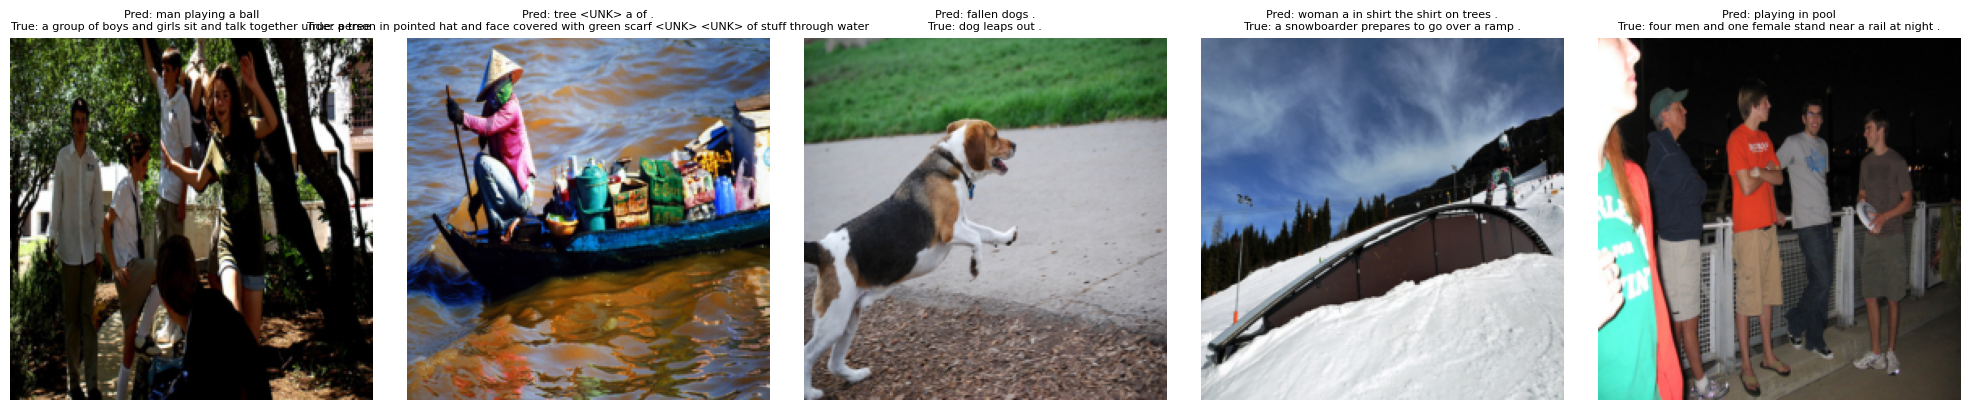

In [9]:
def test_random_images(model, dataset, vocab, device, num_images=5):
    model.eval()
    indices = np.random.choice(len(dataset), num_images, replace=False)

    fig, axes = plt.subplots(1, num_images, figsize=(20, 4))

    for i, idx in enumerate(indices):
        image, caption_vec = dataset[idx]

        # Sinh caption
        pred_caption = model.caption_image(image, vocab, device)

        # Ground truth
        true_caption = []
        for id in caption_vec[1:]:
            if id == vocab.stoi["<EOS>"] or id == vocab.stoi["<PAD>"]:
                break
            true_caption.append(vocab.itos[id.item()])

        # Denormalize ảnh
        img = image.numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        axes[i].set_title(f"Pred: {pred_caption}\nTrue: {' '.join(true_caption)}", fontsize=8)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

test_random_images(model, dataset, vocab, device)

In [10]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
from rouge_score import rouge_scorer # Import RougeScorer

def evaluate_bleu(model, dataset, captions_dict, vocab, device):
    model.eval()
    references  = []   # list of list of list for BLEU
    hypotheses  = []   # list of list for BLEU

    references_text = [] # list of list of string for ROUGE
    hypotheses_text = [] # list of string for ROUGE

    # Lấy TẤT CẢ indices từ val_dataset để đánh giá toàn bộ
    indices = range(len(val_dataset))

    for idx in indices:
        # Get the original index from the Subset
        original_idx = val_dataset.indices[idx]
        image, _ = val_dataset[idx]
        # Access img_name from the original dataset using the original index
        img_name  = dataset.imgs[original_idx]

        # 5 caption đúng của ảnh này
        refs = [
            nltk.word_tokenize(cap.lower())
            for cap in captions_dict[img_name]
        ]
        references.append(refs)
        references_text.append([cap.lower() for cap in captions_dict[img_name]]) # Store raw captions for ROUGE

        # Caption model sinh ra
        pred = model.caption_image(image, vocab, device)
        hypotheses.append(nltk.word_tokenize(pred.lower()))
        hypotheses_text.append(pred.lower()) # Store raw prediction for ROUGE

    # Initialize smoothing function for BLEU
    chencherry = SmoothingFunction()

    # Tính BLEU-1 đến BLEU-4 với smoothing
    bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=chencherry.method1)
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=chencherry.method1)
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=chencherry.method1)

    print(f"BLEU-1: {bleu1:.4f}")
    print(f"BLEU-2: {bleu2:.4f}")
    print(f"BLEU-4: {bleu4:.4f}")

    # Calculate ROUGE scores
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []

    for i in range(len(hypotheses_text)):
        # RougeScorer expects a list of reference strings, so we pass references_text[i]
        # Use the first reference for now, or adapt if multiple refs are needed per hypothesis
        scores = scorer.score(references_text[i][0], hypotheses_text[i])
        rouge1_scores.append(scores['rouge1'].fmeasure)
        rouge2_scores.append(scores['rouge2'].fmeasure)
        rougeL_scores.append(scores['rougeL'].fmeasure)

    avg_rouge1 = np.mean(rouge1_scores)
    avg_rouge2 = np.mean(rouge2_scores)
    avg_rougeL = np.mean(rougeL_scores)

    print(f"ROUGE-1 F-measure: {avg_rouge1:.4f}")
    print(f"ROUGE-2 F-measure: {avg_rouge2:.4f}")
    print(f"ROUGE-L F-measure: {avg_rougeL:.4f}")

    return bleu1, bleu2, bleu4, avg_rouge1, avg_rouge2, avg_rougeL

# Gọi sau khi train xong
evaluate_bleu(model, dataset, captions_dict, vocab, device)

BLEU-1: 0.3245
BLEU-2: 0.0334
BLEU-4: 0.0006
ROUGE-1 F-measure: 0.1501
ROUGE-2 F-measure: 0.0009
ROUGE-L F-measure: 0.1351


(0.32451438986444553,
 0.03336711831545436,
 0.0005697175008022867,
 np.float64(0.15005217329716197),
 np.float64(0.0009095350857069432),
 np.float64(0.13513246207066487))

In [11]:
print(val_dataset.indices[1])
print(np.random.choice(len(val_dataset), 100, replace=False))

342
[1606  992 1476  129  498 1362 1327  247  650  946   51  294  666  315
  115  535 1332  144  425 1368  321 1437  812  585 1074 1171  845 1158
  148  656 1588  190 1594 1550  718  635  682 1343  638  137 1210 1586
  521   93  899  235 1372 1323 1549 1120  271 1150  476 1613  430  574
  412 1484  406 1232   88  403 1160 1609  641   40  986 1405  781 1103
  779  240  589 1460  913 1192 1181 1616  934 1374  100  359  945  420
 1249 1328 1378    6  802  231 1582  547  685  208  910 1163 1486  169
  759  663]


Saving eda_num_answers.png to eda_num_answers.png


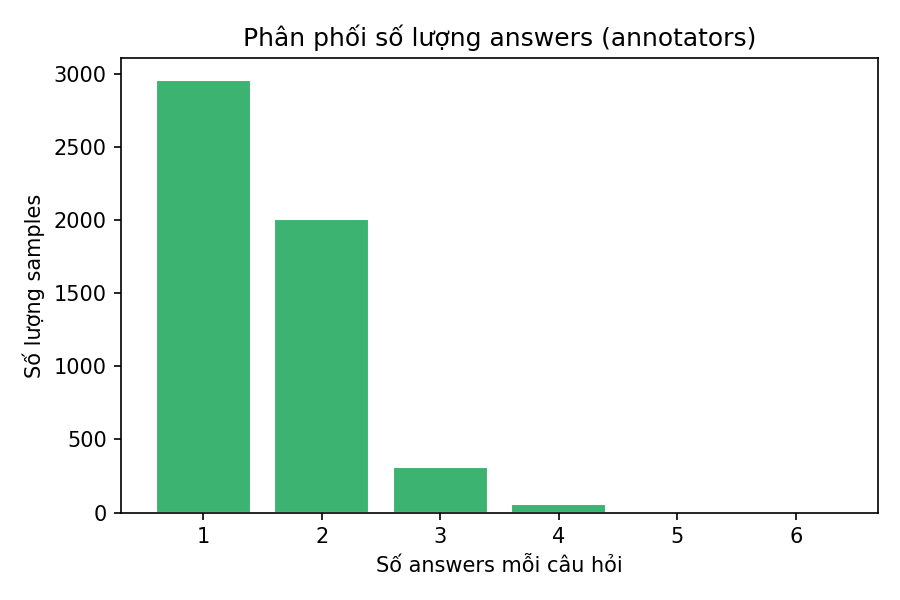

📝 Generated Caption: sheep a with , standing a in water


In [12]:
from google.colab import files
from IPython.display import Image as IPImage, display
import io

def upload_and_caption():
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Load ảnh
        image = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')

        # Transform
        img_tensor = transform(image).unsqueeze(0)

        # Predict
        model.eval()
        with torch.no_grad():
            caption = model.caption_image(img_tensor.squeeze(0), vocab, device)

        # Hiển thị
        display(IPImage(uploaded[filename], width=400))
        print(f"📝 Generated Caption: {caption}")

# Chạy cell này và upload ảnh
upload_and_caption()